<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/04_models_training_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Image Classification - Model Training with Checkpointing
## Handles Colab disconnections with automatic resume capability

In [2]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from pathlib import Path
from datetime import datetime
import pickle

warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration with Checkpointing Support

In [4]:
class Config:
    """Global configuration for all models"""

    # Paths
    BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"
    SPLIT_DIR = f"{BASE_DIR}/data/split"
    RESULTS_DIR = f"{BASE_DIR}/results/benchmarks"
    CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"

    # NEW: Progress tracking
    PROGRESS_FILE = f"{CHECKPOINT_DIR}/training_progress.json"

    # Training parameters
    BATCH_SIZE = 32
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Random seed
    SEED = 42

    # Datasets to train on
    DATASETS = [
        "MRI_tumor_binary_norm",
        "MRI_tumor_multiclass_norm",
        "MRI_ms_norm",
        "CT_stroke_binary_norm"
    ]

    # Models to benchmark
    MODELS = [
        "resnet50",
        "resnet101",
        "vgg16",
        "densenet121",
        "densenet169",
        "mobilenet_v2",
        "efficientnet_b0",
        "efficientnet_b4",
    ]

    # Early stopping
    PATIENCE = 10
    MIN_DELTA = 1e-3

    # NEW: Checkpoint saving frequency (save every N epochs)
    CHECKPOINT_FREQ = 2

    def __init__(self):
        os.makedirs(self.RESULTS_DIR, exist_ok=True)
        os.makedirs(self.CHECKPOINT_DIR, exist_ok=True)

## Progress Tracker

In [5]:
class ProgressTracker:
    """Track training progress across Colab sessions"""

    def __init__(self, progress_file):
        self.progress_file = progress_file
        self.progress = self.load_progress()

    def load_progress(self):
        """Load existing progress or create new"""
        if os.path.exists(self.progress_file):
            with open(self.progress_file, 'r') as f:
                return json.load(f)
        return {
            'completed': [],
            'in_progress': None,
            'last_epoch': 0,
            'results': {}
        }

    def save_progress(self):
        """Save progress to disk"""
        os.makedirs(os.path.dirname(self.progress_file), exist_ok=True)
        with open(self.progress_file, 'w') as f:
            json.dump(self.progress, f, indent=2)

    def is_completed(self, dataset, model):
        """Check if dataset-model combination is already done"""
        return [dataset, model] in self.progress['completed']

    def mark_started(self, dataset, model):
        """Mark a dataset-model pair as started"""
        self.progress['in_progress'] = [dataset, model]
        self.progress['last_epoch'] = 0
        self.save_progress()

    def update_epoch(self, epoch):
        """Update last completed epoch"""
        self.progress['last_epoch'] = epoch
        self.save_progress()

    def mark_completed(self, dataset, model, results):
        """Mark a dataset-model pair as completed"""
        self.progress['completed'].append([dataset, model])

        if dataset not in self.progress['results']:
            self.progress['results'][dataset] = {}
        self.progress['results'][dataset][model] = results

        self.progress['in_progress'] = None
        self.progress['last_epoch'] = 0
        self.save_progress()

    def get_resume_info(self, dataset, model):
        """Get info to resume training"""
        if (self.progress['in_progress'] == [dataset, model] and
            self.progress['last_epoch'] > 0):
            return self.progress['last_epoch']
        return 0

    def get_results(self):
        """Get all completed results"""
        return self.progress['results']

    def print_status(self):
        """Print current progress status"""
        print("\n" + "="*70)
        print("TRAINING PROGRESS STATUS")
        print("="*70)
        print(f"Completed: {len(self.progress['completed'])} dataset-model pairs")

        if self.progress['completed']:
            print("\nCompleted pairs:")
            for dataset, model in self.progress['completed']:
                print(f"  ✓ {dataset} - {model}")

        if self.progress['in_progress']:
            dataset, model = self.progress['in_progress']
            print(f"\nIn Progress: {dataset} - {model}")
            print(f"  Last epoch: {self.progress['last_epoch']}")

        print("="*70 + "\n")

## Dataset Class

In [6]:
class MedicalImageDataset(Dataset):
    """PyTorch Dataset for medical images with stratified splits"""

    def __init__(self, split_dir, split_type="train", transform=None):
        """
        Args:
            split_dir: path to split directory
            split_type: "train", "val", or "test"
            transform: image transformations
        """
        self.split_dir = split_dir
        self.split_type = split_type
        self.transform = transform

        self.samples = []
        self.class_to_idx = {}
        self._build_samples()

    def _build_samples(self):
        """Build list of (path, label) tuples"""
        split_path = os.path.join(self.split_dir, self.split_type)

        idx = 0
        for class_name in sorted(os.listdir(split_path)):
            class_path = os.path.join(split_path, class_name)

            if not os.path.isdir(class_path):
                continue

            if class_name not in self.class_to_idx:
                self.class_to_idx[class_name] = idx
                idx += 1

            label = self.class_to_idx[class_name]

            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from PIL import Image

        img_path, label = self.samples[idx]

        # Load as grayscale and convert to RGB (3 channels for pretrained models)
        image = Image.open(img_path).convert('L')
        image_rgb = Image.new('RGB', image.size)
        image_rgb.paste(image)

        if self.transform:
            image_rgb = self.transform(image_rgb)

        return image_rgb, label

In [7]:
def get_data_loaders(split_dir, batch_size=32, num_workers=2):
    """Create train/val/test DataLoaders"""

    # ImageNet normalization
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    # Training transforms (with augmentation)
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=5, scale=(0.9, 1.1)),
        transforms.ToTensor(),
        normalize,
    ])

    # Val/Test transforms (no augmentation)
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize,
    ])

    # Create datasets
    train_ds = MedicalImageDataset(split_dir, "train", train_transform)
    val_ds = MedicalImageDataset(split_dir, "val", test_transform)
    test_ds = MedicalImageDataset(split_dir, "test", test_transform)

    # Create loaders
    loaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                           num_workers=num_workers, pin_memory=True),
        'val': DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=True),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True),
    }

    return loaders, train_ds.class_to_idx

In [8]:
def create_model(model_name, num_classes, pretrained=True):
    """Create model with specified architecture"""

    if model_name == "resnet50":
        model = models.resnet50(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet101":
        model = models.resnet101(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(pretrained=pretrained)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    elif model_name == "vgg19":
        model = models.vgg19(pretrained=pretrained)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(pretrained=pretrained)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "densenet169":
        model = models.densenet169(pretrained=pretrained)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "inception_v3":
        model = models.inception_v3(pretrained=pretrained)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "efficientnet_b4":
        model = models.efficientnet_b4(pretrained=pretrained)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model

## Early Stopping with Enhanced State Saving

In [9]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""

    def __init__(self, patience=10, min_delta=0.0, restore_best=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best
        self.counter = 0
        self.best_loss = None
        self.best_epoch = None
        self.best_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_state = model.state_dict().copy()
            self.best_epoch = 0
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = model.state_dict().copy()
            self.best_epoch = 0
        else:
            self.counter += 1
            self.best_epoch += 1

        return self.counter >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None and self.restore_best:
            model.load_state_dict(self.best_state)

    def state_dict(self):
        """Return state for checkpointing"""
        return {
            'counter': self.counter,
            'best_loss': self.best_loss,
            'best_epoch': self.best_epoch,
            'best_state': self.best_state
        }

    def load_state_dict(self, state):
        """Load state from checkpoint"""
        self.counter = state['counter']
        self.best_loss = state['best_loss']
        self.best_epoch = state['best_epoch']
        self.best_state = state['best_state']

## Training Functions with Checkpointing

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        with torch.no_grad():
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

        pbar.update(1)

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    avg_acc = accuracy_score(all_labels, all_preds)

    return avg_loss, avg_acc

In [11]:
def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch"""
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating", leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1).cpu().numpy()
            probs = torch.softmax(outputs, dim=1).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs)

            pbar.update(1)

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    avg_acc = accuracy_score(all_labels, all_preds)

    # Compute AUC
    try:
        if len(np.unique(all_labels)) == 2:
            avg_auc = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            avg_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    except Exception as e:
        print(f"  Warning: Could not compute AUC: {e}")
        avg_auc = 0.0

    return avg_loss, avg_acc, avg_auc

In [12]:
def save_checkpoint(checkpoint_path, model, optimizer, scheduler, early_stop,
                   epoch, history):
    """Save complete checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'early_stop_state': early_stop.state_dict(),
        'history': history,
    }
    torch.save(checkpoint, checkpoint_path)


def load_checkpoint(checkpoint_path, model, optimizer, scheduler, early_stop):
    """Load checkpoint and return start epoch and history"""
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    early_stop.load_state_dict(checkpoint['early_stop_state'])

    return checkpoint['epoch'] + 1, checkpoint['history']

In [13]:
def train_model(model, loaders, criterion, optimizer, scheduler, device,
                num_epochs, model_name, dataset_name, checkpoint_dir,
                progress_tracker, start_epoch=0, resume_history=None):
    """Train model with checkpointing and resume capability"""

    checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}.pt")
    early_stop = EarlyStopping(patience=Config.PATIENCE, min_delta=Config.MIN_DELTA)

    # Resume from checkpoint if available
    if start_epoch > 0 and os.path.exists(checkpoint_path):
        print(f"\n🔄 RESUMING from epoch {start_epoch}")
        try:
            start_epoch, history = load_checkpoint(
                checkpoint_path, model, optimizer, scheduler, early_stop
            )
            model = model.to(device)
        except Exception as e:
            print(f"⚠️  Failed to load checkpoint: {e}")
            print("Starting from scratch...")
            start_epoch = 0
            history = {
                'train_loss': [], 'train_acc': [],
                'val_loss': [], 'val_acc': [], 'val_auc': []
            }
    else:
        history = resume_history if resume_history else {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': [], 'val_auc': []
        }

    print(f"\n{'='*70}")
    print(f"Training {model_name} on {dataset_name}")
    print(f"Epochs: {start_epoch} → {num_epochs}")
    print(f"{'='*70}")

    for epoch in range(start_epoch, num_epochs):
        train_loss, train_acc = train_epoch(
            model, loaders['train'], criterion, optimizer, device
        )

        val_loss, val_acc, val_auc = validate_epoch(
            model, loaders['val'], criterion, device
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)

        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"TrLoss: {train_loss:.4f} | TrAcc: {train_acc:.4f} | "
              f"VaLoss: {val_loss:.4f} | VaAcc: {val_acc:.4f} | VaAUC: {val_auc:.4f}")

        if scheduler is not None:
            scheduler.step(val_loss)

        # Save checkpoint every N epochs
        if (epoch + 1) % Config.CHECKPOINT_FREQ == 0:
            save_checkpoint(
                checkpoint_path, model, optimizer, scheduler,
                early_stop, epoch, history
            )
            progress_tracker.update_epoch(epoch)
            print(f"  💾 Checkpoint saved (epoch {epoch+1})")

        if early_stop(val_loss, model):
            print(f"Early stopping at epoch {epoch+1}")
            early_stop.restore_best_weights(model)
            # Save final checkpoint
            save_checkpoint(
                checkpoint_path, model, optimizer, scheduler,
                early_stop, epoch, history
            )
            break

    # Save final model
    final_model_path = os.path.join(checkpoint_dir, f"{model_name}_{dataset_name}_final.pt")
    torch.save(model.state_dict(), final_model_path)

    return history, final_model_path

In [14]:
def evaluate_model(model, loader, device):
    """Full evaluation metrics"""
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1).cpu().numpy()
            probs = torch.softmax(outputs, dim=1).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs)

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    }

    # AUC
    try:
        if len(np.unique(all_labels)) == 2:
            metrics['auc'] = roc_auc_score(all_labels, all_probs[:, 1])
        else:
            metrics['auc'] = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    except Exception as e:
        print(f"  Warning: Could not compute AUC: {e}")
        metrics['auc'] = 0.0

    return metrics, all_preds, all_labels

In [15]:
def save_results(results, output_path):
    """Save results to JSON"""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(results, f, indent=2, default=str)

## Main Training Loop with Resume Capability

In [16]:
# Initialize
config = Config()
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)

# Load progress tracker
progress_tracker = ProgressTracker(config.PROGRESS_FILE)
progress_tracker.print_status()

# Get existing results or start fresh
all_results = progress_tracker.get_results()


TRAINING PROGRESS STATUS
Completed: 26 dataset-model pairs

Completed pairs:
  ✓ MRI_tumor_binary_norm - resnet50
  ✓ MRI_tumor_binary_norm - resnet101
  ✓ MRI_tumor_binary_norm - vgg16
  ✓ MRI_tumor_binary_norm - densenet121
  ✓ MRI_tumor_binary_norm - densenet169
  ✓ MRI_tumor_binary_norm - mobilenet_v2
  ✓ MRI_tumor_binary_norm - efficientnet_b0
  ✓ MRI_tumor_binary_norm - efficientnet_b4
  ✓ MRI_tumor_multiclass_norm - resnet50
  ✓ MRI_tumor_multiclass_norm - resnet101
  ✓ MRI_tumor_multiclass_norm - vgg16
  ✓ MRI_tumor_multiclass_norm - densenet121
  ✓ MRI_tumor_multiclass_norm - densenet169
  ✓ MRI_tumor_multiclass_norm - mobilenet_v2
  ✓ MRI_tumor_multiclass_norm - efficientnet_b0
  ✓ MRI_tumor_multiclass_norm - efficientnet_b4
  ✓ MRI_ms_norm - resnet50
  ✓ MRI_ms_norm - resnet101
  ✓ MRI_ms_norm - vgg16
  ✓ MRI_ms_norm - densenet121
  ✓ MRI_ms_norm - densenet169
  ✓ MRI_ms_norm - mobilenet_v2
  ✓ MRI_ms_norm - efficientnet_b0
  ✓ MRI_ms_norm - efficientnet_b4
  ✓ CT_stroke_bi

In [17]:
# Main training loop
for dataset_name in config.DATASETS:
    dataset_path = os.path.join(config.SPLIT_DIR, dataset_name)

    if not os.path.exists(dataset_path):
        print(f"Dataset not found: {dataset_path}")
        continue

    print(f"\n\n{'#'*70}")
    print(f"# DATASET: {dataset_name}")
    print(f"{'#'*70}")

    loaders, class_to_idx = get_data_loaders(
        dataset_path,
        batch_size=config.BATCH_SIZE,
        num_workers=2
    )

    num_classes = len(class_to_idx)
    print(f"Number of classes: {num_classes}")
    print(f"Classes: {list(class_to_idx.keys())}")

    if dataset_name not in all_results:
        all_results[dataset_name] = {}

    for model_name in config.MODELS:
        # Skip if already completed
        if progress_tracker.is_completed(dataset_name, model_name):
            print(f"\n✓ Skipping {model_name} (already completed)")
            continue

        try:
            print(f"\n--- Training {model_name} ---")

            # Mark as started
            progress_tracker.mark_started(dataset_name, model_name)

            # Check if we're resuming
            resume_epoch = progress_tracker.get_resume_info(dataset_name, model_name)

            model = create_model(model_name, num_classes, pretrained=True)
            model = model.to(config.DEVICE)

            total_params = sum(p.numel() for p in model.parameters())
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"Parameters: {total_params/1e6:.2f}M (trainable: {trainable_params/1e6:.2f}M)")

            criterion = nn.CrossEntropyLoss()

            optimizer = optim.AdamW(
                model.parameters(),
                lr=config.LEARNING_RATE,
                weight_decay=config.WEIGHT_DECAY
            )

            scheduler = ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5
            )

            history, checkpoint_path = train_model(
                model, loaders, criterion, optimizer, scheduler, config.DEVICE,
                config.NUM_EPOCHS, model_name, dataset_name, config.CHECKPOINT_DIR,
                progress_tracker, start_epoch=resume_epoch
            )

            # Load best model for evaluation
            final_model_path = os.path.join(
                config.CHECKPOINT_DIR,
                f"{model_name}_{dataset_name}_final.pt"
            )
            model.load_state_dict(torch.load(final_model_path, map_location=config.DEVICE))

            test_metrics, _, _ = evaluate_model(model, loaders['test'], config.DEVICE)

            print(f"\nTest Results:")
            for metric, value in test_metrics.items():
                print(f"  {metric}: {value:.4f}")

            results = {
                'test_metrics': test_metrics,
                'history': history,
                'params': trainable_params,
            }

            all_results[dataset_name][model_name] = results

            # Mark as completed
            progress_tracker.mark_completed(dataset_name, model_name, results)
            print(f"✓ {model_name} completed and saved")

            # Save intermediate results
            intermediate_path = os.path.join(
                config.RESULTS_DIR,
                f"results_intermediate_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
            )
            save_results(all_results, intermediate_path)

        except Exception as e:
            print(f"❌ Error training {model_name}: {str(e)}")
            all_results[dataset_name][model_name] = {'error': str(e)}
            # Don't mark as completed so it can be retried



######################################################################
# DATASET: MRI_tumor_binary_norm
######################################################################
Number of classes: 2
Classes: ['normal', 'tumor']

✓ Skipping resnet50 (already completed)

✓ Skipping resnet101 (already completed)

✓ Skipping vgg16 (already completed)

✓ Skipping densenet121 (already completed)

✓ Skipping densenet169 (already completed)

✓ Skipping mobilenet_v2 (already completed)

✓ Skipping efficientnet_b0 (already completed)

✓ Skipping efficientnet_b4 (already completed)


######################################################################
# DATASET: MRI_tumor_multiclass_norm
######################################################################
Number of classes: 12
Classes: ['Carcinoma', 'Germinoma', 'Glioma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'Neurocitoma', 'Normal', 'Other', 'Papiloma', 'Schwannoma', 'Tuberculoma']

✓ Skipping resnet50 (already completed)

✓ Skipping r

100%|██████████| 528M/528M [00:05<00:00, 109MB/s]


Parameters: 134.27M (trainable: 134.27M)

Training vgg16 on CT_stroke_binary_norm
Epochs: 0 → 20


Epoch   1/20 | TrLoss: 0.4293 | TrAcc: 0.8028 | VaLoss: 0.2849 | VaAcc: 0.8776 | VaAUC: 0.9518


Epoch   2/20 | TrLoss: 0.3133 | TrAcc: 0.8782 | VaLoss: 0.6619 | VaAcc: 0.7974 | VaAUC: 0.9549
  💾 Checkpoint saved (epoch 2)


...

Epoch  13/20 | TrLoss: 0.0868 | TrAcc: 0.9656 | VaLoss: 0.1841 | VaAcc: 0.9408 | VaAUC: 0.9842


Epoch  14/20 | TrLoss: 0.0669 | TrAcc: 0.9749 | VaLoss: 0.2135 | VaAcc: 0.9458 | VaAUC: 0.9854
  💾 Checkpoint saved (epoch 14)


Epoch  15/20 | TrLoss: 0.0759 | TrAcc: 0.9734 | VaLoss: 0.1873 | VaAcc: 0.9468 | VaAUC: 0.9859


Epoch  16/20 | TrLoss: 0.0707 | TrAcc: 0.9751 | VaLoss: 0.2012 | VaAcc: 0.9488 | VaAUC: 0.9876
  💾 Checkpoint saved (epoch 16)
Early stopping at epoch 16



Test Results:
  accuracy: 0.9690
  precision: 0.9690
  recall: 0.9690
  f1: 0.9688
  auc: 0.9944
✓ efficientnet_b4 completed and saved


## Save Final Results

In [18]:
results_path = os.path.join(
    config.RESULTS_DIR,
    f"benchmark_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
)
save_results(all_results, results_path)

print(f"\n\n{'#'*70}")
print(f"# SUMMARY")
print(f"{'#'*70}")

summary_df = []
for dataset_name, models in all_results.items():
    for model_name, results in models.items():
        if 'test_metrics' in results:
            row = {
                'dataset': dataset_name,
                'model': model_name,
                'accuracy': results['test_metrics']['accuracy'],
                'f1': results['test_metrics']['f1'],
                'auc': results['test_metrics']['auc'],
            }
            summary_df.append(row)

summary_df = pd.DataFrame(summary_df)
summary_df = summary_df.sort_values('accuracy', ascending=False)

print("\nTop Results (by Accuracy):")
print(summary_df.head(10).to_string(index=False))

summary_path = os.path.join(
    config.RESULTS_DIR,
    f"summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
)
summary_df.to_csv(summary_path, index=False)

print(f"\nResults saved to: {results_path}")
print(f"Summary saved to: {summary_path}")

# Print final progress status
progress_tracker.print_status()



######################################################################
# SUMMARY
######################################################################

Top Results (by Accuracy):
                  dataset           model  accuracy       f1      auc
    MRI_tumor_binary_norm           vgg16  1.000000 1.000000 1.000000
    MRI_tumor_binary_norm       resnet101  0.997778 0.997778 0.999980
    MRI_tumor_binary_norm efficientnet_b0  0.997778 0.997778 0.999960
    MRI_tumor_binary_norm     densenet169  0.997778 0.997778 0.999980
    MRI_tumor_binary_norm efficientnet_b4  0.997778 0.997778 0.999901
    MRI_tumor_binary_norm        resnet50  0.995556 0.995556 0.999802
    MRI_tumor_binary_norm     densenet121  0.995556 0.995556 0.999881
    MRI_tumor_binary_norm    mobilenet_v2  0.993333 0.993333 1.000000
MRI_tumor_multiclass_norm     densenet169  0.989975 0.989967 0.999887
MRI_tumor_multiclass_norm       resnet101  0.983292 0.983274 0.999764

Results saved to: /content/drive/MyDrive/MSc_Th

## Generate Results Table

In [20]:
import json, pandas as pd, os
from pathlib import Path

RESULTS_DIR = config.RESULTS_DIR

# Find most recent results file
results_file = max(Path(RESULTS_DIR).glob("benchmark_results_*.json"), key=os.path.getctime)
with open(results_file, 'r') as f:
    all_results = json.load(f)

data = []
for dataset, models in all_results.items():
    for model, results in models.items():
        if 'test_metrics' in results:
            data.append({
                'dataset': dataset, 'model': model,
                'accuracy': results['test_metrics']['accuracy']*100,
                'auc': results['test_metrics']['auc']*100
            })

df = pd.DataFrame(data)

models = ['resnet50','resnet101','vgg16','densenet121','densenet169','mobilenet_v2','efficientnet_b0','efficientnet_b4']
datasets = ['MRI_tumor_binary_norm','MRI_tumor_multiclass_norm','MRI_ms_norm', 'CT_stroke_binary_norm']

table = "| Model | " + " | ".join([d.replace('_norm','') for d in datasets]) + " |\n"
table += "|-------|" + "---|"*len(datasets) + "\n"

for model in models:
    row = f"| {model.replace('efficientnet','EffNet')} |"
    for dataset in datasets:
        acc = df[(df.model==model) & (df.dataset==dataset)].accuracy
        row += f" {acc.values[0]:.1f}% |" if len(acc)>0 else " - |"
    table += row + "\n"

print("## FINAL TABLE")
print(table)

with open(os.path.join(RESULTS_DIR, "FINAL_TABLE.md"), "w") as f:
    f.write(table)
print("✓ Saved: FINAL_TABLE.md")

## FINAL TABLE
| Model | MRI_tumor_binary | MRI_tumor_multiclass | MRI_ms | CT_stroke_binary |
|-------|---|---|---|---|
| resnet50 | 99.6% | 95.6% | 53.6% | 94.7% |
| resnet101 | 99.8% | 98.3% | 59.7% | 97.0% |
| vgg16 | 100.0% | 97.2% | 58.5% | 95.8% |
| densenet121 | 99.6% | 98.0% | 46.6% | 97.2% |
| densenet169 | 99.8% | 99.0% | 50.3% | 97.7% |
| mobilenet_v2 | 99.3% | 97.1% | 52.6% | 97.6% |
| EffNet_b0 | 99.8% | 98.1% | 50.7% | 97.0% |
| EffNet_b4 | 99.8% | 98.0% | 54.1% | 96.9% |

✓ Saved: FINAL_TABLE.md


Loaded your results:
dataset       CT_stroke_binary  MRI_ms  MRI_tumor_binary  MRI_tumor_multiclass
model                                                                         
EffNet_b0                 97.0    50.7              99.8                  98.1
EffNet_b4                 96.9    54.1              99.8                  98.0
densenet121               97.2    46.6              99.6                  98.0
densenet169               97.7    50.3              99.8                  99.0
mobilenet_v2              97.6    52.6              99.3                  97.1
resnet101                 97.0    59.7              99.8                  98.3
resnet50                  94.7    53.6              99.6                  95.6
vgg16                     95.8    58.5             100.0                  97.2


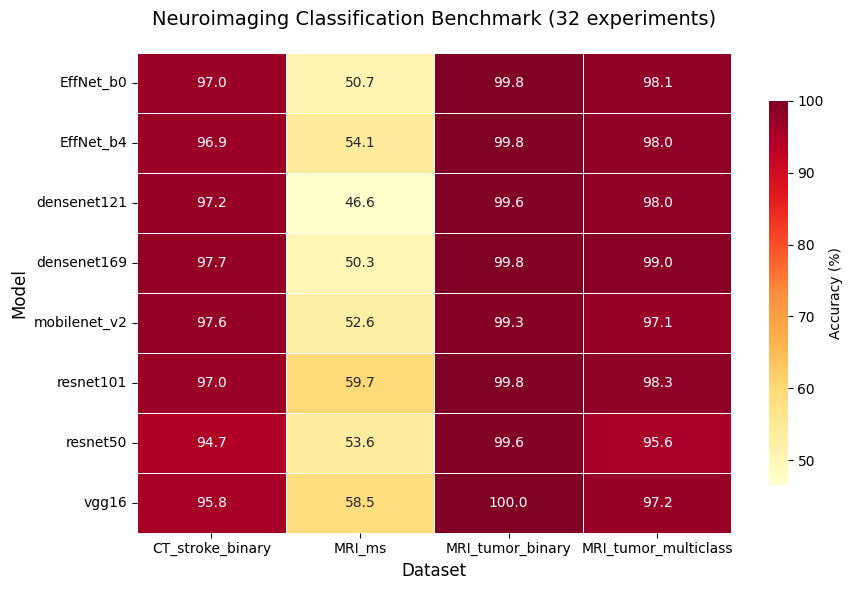

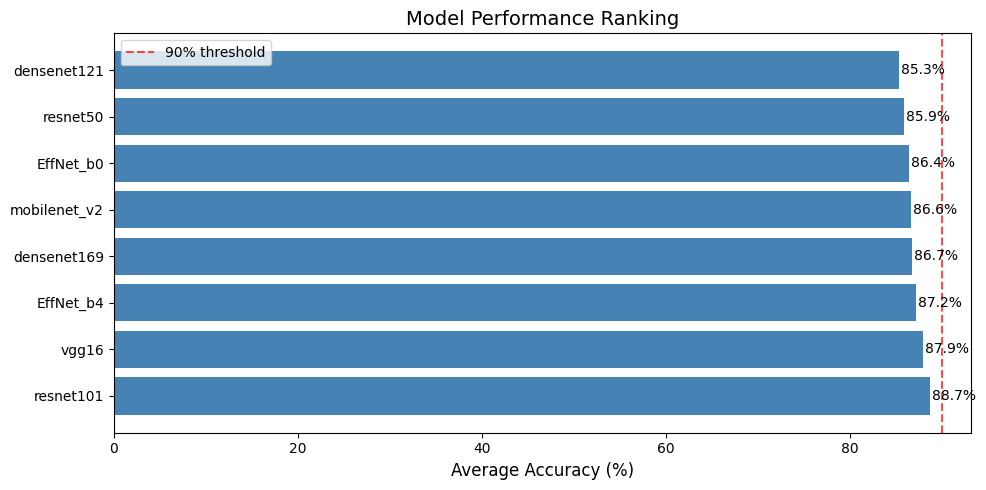


🏆 TOP MODELS:
model
resnet101       88.7
vgg16           87.9
EffNet_b4       87.2
densenet169     86.7
mobilenet_v2    86.6
EffNet_b0       86.4
resnet50        85.9
densenet121     85.3
Name: accuracy, dtype: float64


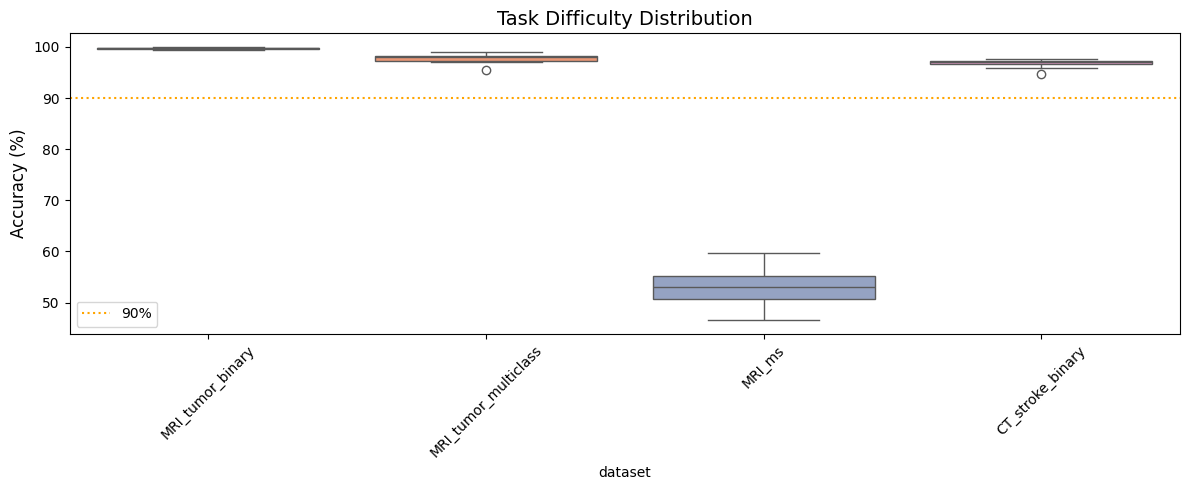

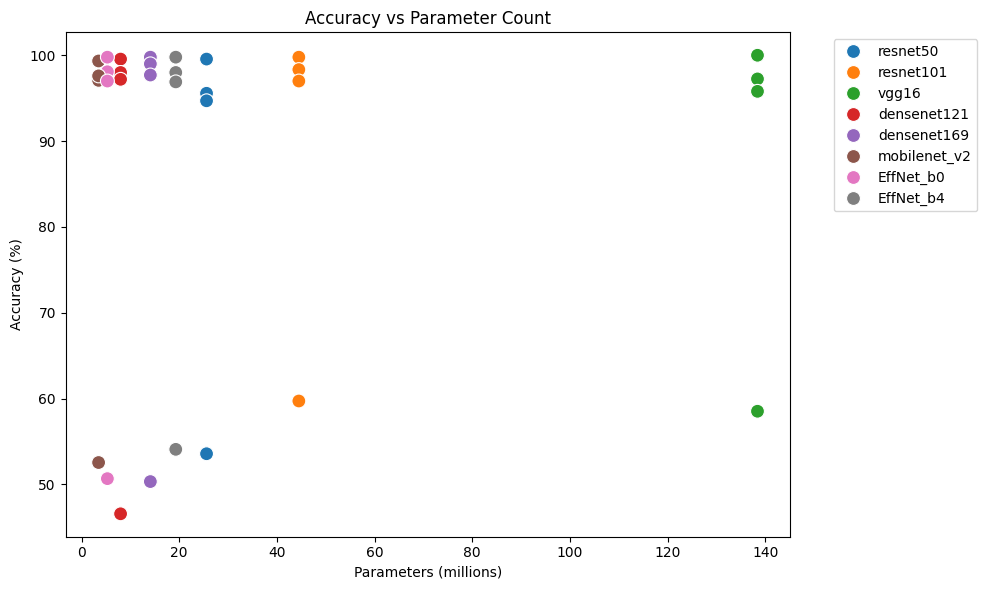


📊 SUMMARY STATS FROM YOUR JSON:
                      mean  std
dataset                        
CT_stroke_binary      96.7  1.0
MRI_ms                53.3  4.3
MRI_tumor_binary      99.7  0.2
MRI_tumor_multiclass  97.7  1.0


In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

results_dir = Path("/content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/benchmarks/")
results_file = results_dir / "benchmark_results_20260208_214002.json"

with open(results_file, 'r') as f:
    all_results = json.load(f)

data = []
for dataset, models in all_results.items():
    for model, results in models.items():
        if 'test_metrics' in results:
            data.append({
                'dataset': dataset.replace('_norm', ''),
                'model': model.replace('efficientnet_', 'EffNet_'),
                'accuracy': results['test_metrics']['accuracy'] * 100,
                'f1': results['test_metrics']['f1'] * 100,
                'auc': results['test_metrics']['auc'] * 100
            })

df = pd.DataFrame(data)
print("Loaded your results:")
print(df.pivot(index='model', columns='dataset', values='accuracy').round(1))

# === PUBLICATION-READY FIGURES (300 DPI) ===

# FIG 1: HEATMAP (main paper figure)
plt.figure(figsize=(9, 6))
pivot = df.pivot(index='model', columns='dataset', values='accuracy').round(1)
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.1f',
            cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            linewidths=0.5)
plt.title('Neuroimaging Classification Benchmark (32 experiments)', fontsize=14, pad=20)
plt.ylabel('Model', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/benchmarks/heatmap_20.png', dpi=300, bbox_inches='tight')
plt.show()

# FIG 2: MODEL RANKING (average across tasks)
model_avg = df.groupby('model')['accuracy'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.barh(range(len(model_avg)), model_avg.values, color='steelblue')
plt.yticks(range(len(model_avg)), model_avg.index)
plt.xlabel('Average Accuracy (%)', fontsize=12)
plt.title('Model Performance Ranking', fontsize=14)
plt.axvline(90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
plt.legend()
# Add values on bars
for i, v in enumerate(model_avg.values):
    plt.text(v + 0.2, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/benchmarks/model_ranking_20.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🏆 TOP MODELS:")
print(model_avg.round(1))

# FIG 3: TASK DIFFICULTY (boxplots)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='dataset', y='accuracy', palette='Set2')
plt.title('Task Difficulty Distribution', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(90, color='orange', linestyle=':', label='90%')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/benchmarks/task_difficulty_20.png', dpi=300, bbox_inches='tight')
plt.show()

# FIG 4: PARAMETER EFFICIENCY
model_params = {
    'resnet50': 25.6, 'resnet101': 44.5, 'vgg16': 138.4,
    'densenet121': 8.0, 'densenet169': 14.1,
    'mobilenet_v2': 3.5, 'EffNet_b0': 5.3, 'EffNet_b4': 19.3
}
df['params_M'] = df['model'].map(model_params)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='params_M', y='accuracy', hue='model', s=100)
plt.title('Accuracy vs Parameter Count')
plt.xlabel('Parameters (millions)')
plt.ylabel('Accuracy (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/benchmarks/param_efficiency_20.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 SUMMARY STATS FROM YOUR JSON:")
print(df.groupby('dataset')['accuracy'].agg(['mean', 'std']).round(1))
